In [102]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from training_data import build_correlation_matrix

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


Using device: cpu


In [103]:
# Setup Single Simulation
N = 100  # Number of stocks
K = 5    # Number of clusters

# Randomly generate cluster assignments and intra-cluster correlations
cluster_assignments = torch.randint(0, K, (N,), device=device)
intra_corrs = (torch.rand(K, device=device) * 0.5) + 0.5  # Random between 0.5 and 1.0

print(f"Cluster assignments shape: {cluster_assignments.shape}")
print(f"Intra-cluster correlations: {intra_corrs}")


Cluster assignments shape: torch.Size([100])
Intra-cluster correlations: tensor([0.7173, 0.6586, 0.6603, 0.5409, 0.8108])


In [104]:
# Run Simulation Loop
epsilon_start = 0.1
epsilon_end = 0.9
epsilon_step = 0.01

epsilon_values = []
mean_correlations = []
min_eigenvalues = []
epsilon_c = None  # Tipping point

epsilon_steps = torch.arange(epsilon_start, epsilon_end + epsilon_step, epsilon_step, device=device)

for epsilon_val in epsilon_steps:
    epsilon_val = epsilon_val.item()
    
    # Build the correlation matrix for this epsilon step
    corr_matrix = build_correlation_matrix(N, K, cluster_assignments, intra_corrs, epsilon_val)
    
    # Check for tipping point (positive-definiteness)
    is_healthy = True
    try:
        _ = torch.linalg.cholesky(corr_matrix)
    except RuntimeError:
        # Cholesky failed - matrix is no longer positive-definite (tipped)
        is_healthy = False
        if epsilon_c is None:  # Record the first tipping point
            epsilon_c = epsilon_val
            print(f"\nTipping point reached at epsilon = {epsilon_c:.3f}")
    
    # Calculate metrics regardless of whether matrix is positive-definite
    # (eigenvalues can still be computed, they'll just be negative/zero after tipping)
    mean_corr = corr_matrix.mean().item()
    min_eigenval = torch.linalg.eigvalsh(corr_matrix).min().item()
    
    # Append to lists
    epsilon_values.append(epsilon_val)
    mean_correlations.append(mean_corr)
    min_eigenvalues.append(min_eigenval)

print(f"\nSimulation completed. Collected {len(epsilon_values)} data points.")
if epsilon_c is not None:
    print(f"Tipping point occurred at epsilon = {epsilon_c:.3f}")


Built correlation matrix with epsilon=0.100
tensor([[1.0000, 0.1000, 0.6586,  ..., 0.6586, 0.1000, 0.1000],
        [0.1000, 1.0000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
        [0.6586, 0.1000, 1.0000,  ..., 0.6586, 0.1000, 0.1000],
        ...,
        [0.6586, 0.1000, 0.6586,  ..., 1.0000, 0.1000, 0.1000],
        [0.1000, 0.1000, 0.1000,  ..., 0.1000, 1.0000, 0.5409],
        [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.5409, 1.0000]])
Built correlation matrix with epsilon=0.110
tensor([[1.0000, 0.1100, 0.6586,  ..., 0.6586, 0.1100, 0.1100],
        [0.1100, 1.0000, 0.1100,  ..., 0.1100, 0.1100, 0.1100],
        [0.6586, 0.1100, 1.0000,  ..., 0.6586, 0.1100, 0.1100],
        ...,
        [0.6586, 0.1100, 0.6586,  ..., 1.0000, 0.1100, 0.1100],
        [0.1100, 0.1100, 0.1100,  ..., 0.1100, 1.0000, 0.5409],
        [0.1100, 0.1100, 0.1100,  ..., 0.1100, 0.5409, 1.0000]])
Built correlation matrix with epsilon=0.120
tensor([[1.0000, 0.1200, 0.6586,  ..., 0.6586, 0.1200, 0.1200],
        

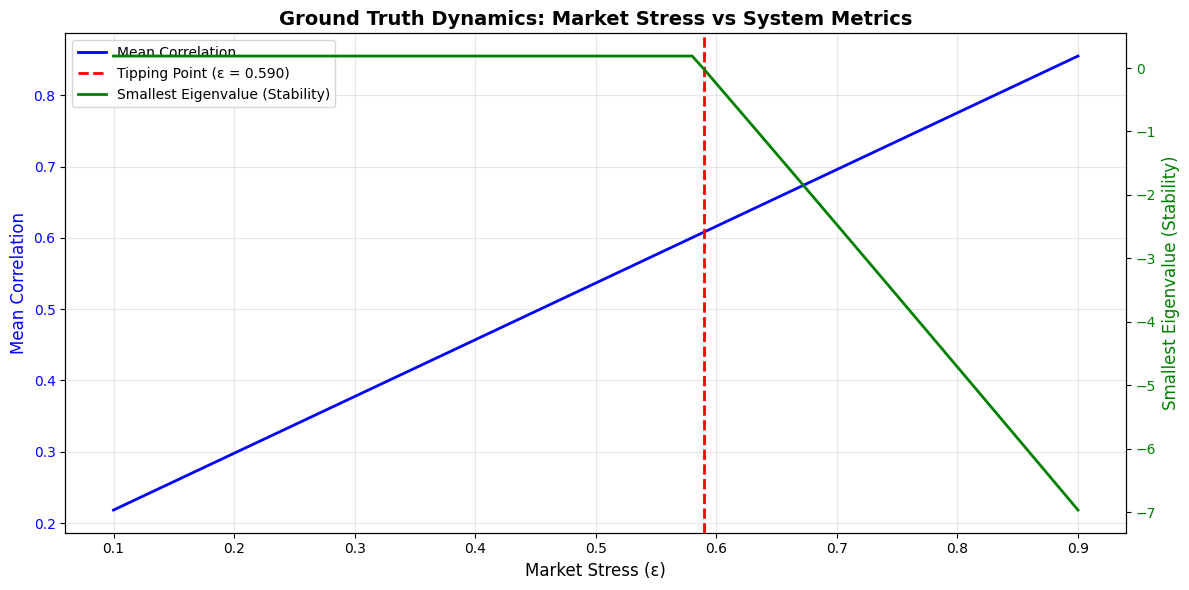

In [105]:
# Visualize the Plots
fig, ax1 = plt.subplots(figsize=(12, 6))

# Create second y-axis
ax2 = ax1.twinx()

# Plot 1: Mean Correlation (Left Axis)
ax1.plot(epsilon_values, mean_correlations, color='blue', label='Mean Correlation', linewidth=2)
ax1.set_xlabel('Market Stress (ε)', fontsize=12)
ax1.set_ylabel('Mean Correlation', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Plot 2: Smallest Eigenvalue (Right Axis)
ax2.plot(epsilon_values, min_eigenvalues, color='green', label='Smallest Eigenvalue (Stability)', linewidth=2)
ax2.set_ylabel('Smallest Eigenvalue (Stability)', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')

# Plot vertical line at tipping point
if epsilon_c is not None:
    ax1.axvline(x=epsilon_c, color='red', linestyle='--', linewidth=2, label=f'Tipping Point (ε = {epsilon_c:.3f})')

# Add title and legend
ax1.set_title('Ground Truth Dynamics: Market Stress vs System Metrics', fontsize=14, fontweight='bold')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=10)

# Add grid for better readability
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
